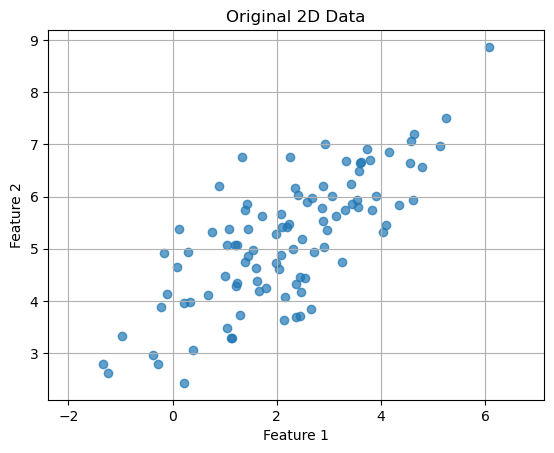

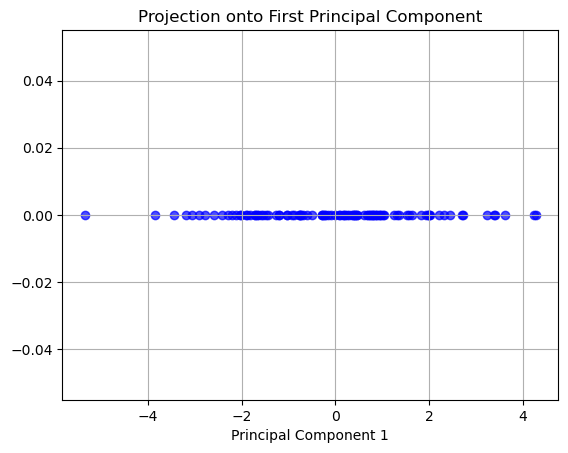

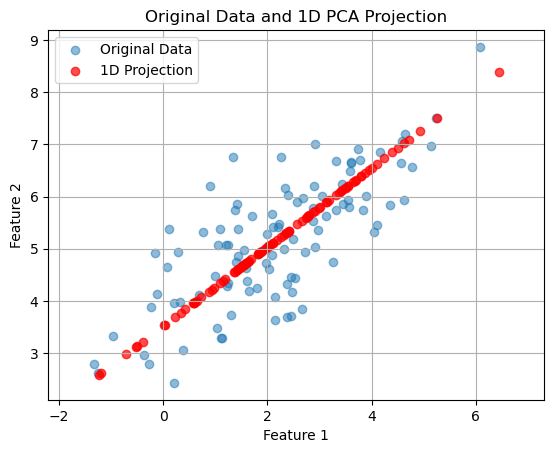

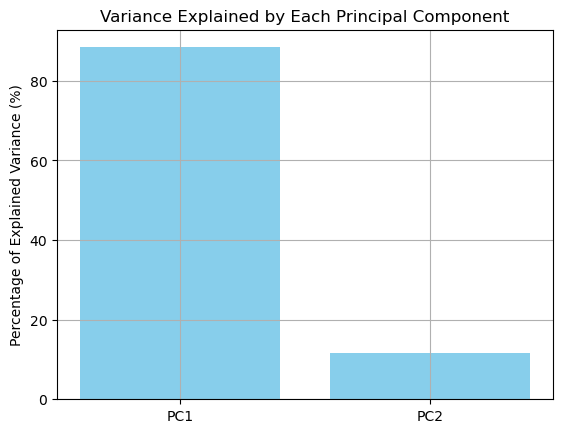

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1
np.random.seed(42)
X = np.random.multivariate_normal(mean=[2, 5], cov=[[3, 2], [2, 2]], size=100)

plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Original 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.grid(True)
plt.show()

# 2
X_centered = X - np.mean(X, axis=0)

# 3
cov_matrix = np.cov(X_centered, rowvar=False)

# 4
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# 5
pc1 = eigenvectors[:, 0]
X_projected = X_centered @ pc1

# 6
plt.scatter(X_projected, np.zeros_like(X_projected), alpha=0.7, color='blue')
plt.title("Projection onto First Principal Component")
plt.xlabel("Principal Component 1")
plt.grid(True)
plt.show()
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data')
line_pc1 = np.outer(X_projected, pc1) + np.mean(X, axis=0)
plt.scatter(line_pc1[:, 0], line_pc1[:, 1], alpha=0.7, color='red', label='1D Projection')
plt.title("Original Data and 1D PCA Projection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# 7
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.bar(["PC1", "PC2"], explained_variance_ratio * 100, color='skyblue')
plt.ylabel("Percentage of Explained Variance (%)")
plt.title("Variance Explained by Each Principal Component")
plt.grid(True)
plt.show()


Shape of X: (1797, 64)
Shape of Y: (1797,)
Each of the 64 features represents pixel intensity from an 8x8 image (flattened).


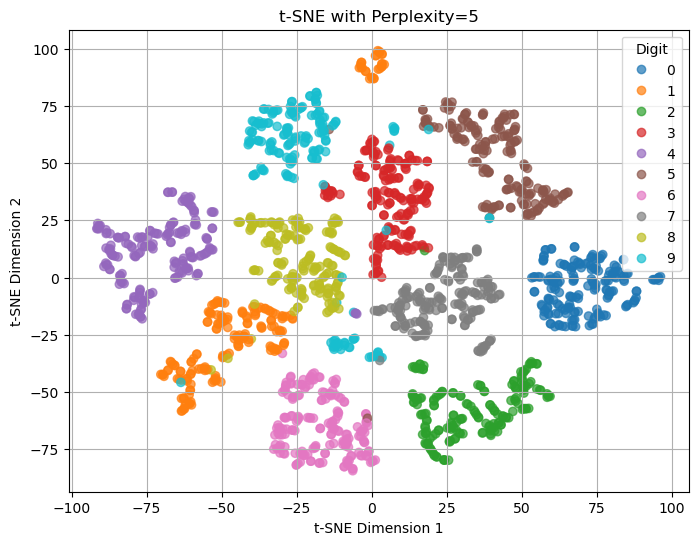

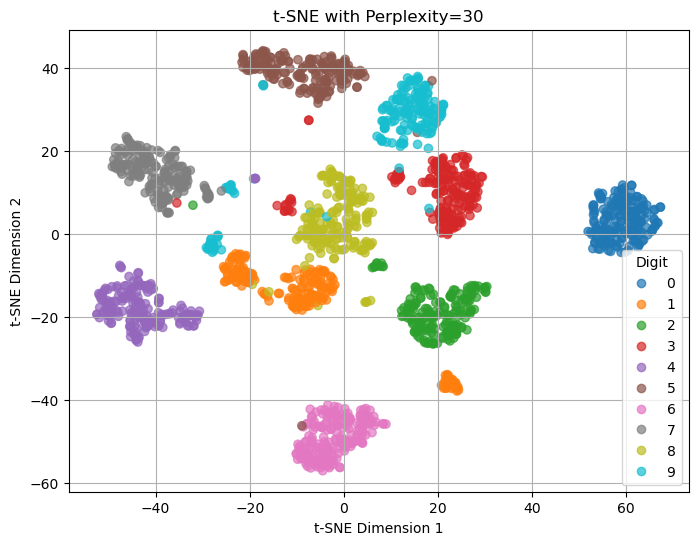

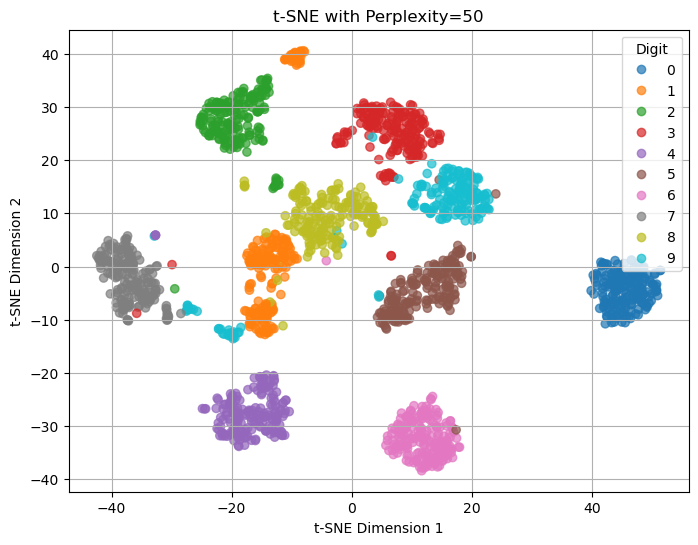

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE

digits = load_digits()
X = digits.data
Y = digits.target

# 1
print("Shape of X:", X.shape)  
print("Shape of Y:", Y.shape)  
print("Each of the 64 features represents pixel intensity from an 8x8 image (flattened).")

# 2 , 3
def plot_tsne(X_embedded, y, perplexity):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, cmap='tab10', alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Digit")
    plt.title(f"t-SNE with Perplexity={perplexity}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.show()

# 4
for perplexity in [5, 30, 50]:
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='random')
    X_embedded = tsne.fit_transform(X)
    plot_tsne(X_embedded, Y, perplexity)
